# Progress report 2: Microstrip
**Date:** 26-03-2026
**AUTHOR:** Mateo IBARRA GOMEZ

This report summarizes the work done on the HFSS simulations of a microstrip according to Romain's indications in *Simus pour Mateo - 2026-06-03.pptx*.

## Objective
Through HFSS simulations of a microstrip and a CPN waveguide, determine for which parameters the field fills a larger volume of the substrate. The parameters are the width of the line w_line and the height of the substrate h_subs.

## Current goal
I had performed simulations sweeping w_line and h_subs for the microstrip structure, but I got a S11 parameter that variedd strongly with the dimensions. This is not expected when applying a wave port excitation which is the one used here. Therefore, the current goal is to:
- Make corrections to the microstrip simulations in order to have S11 not varying so much with w_line and h_subs.

## Work completed this week
- Identify causes of microstrip simulation problems regarding the variation of S11 with dimensions
- Show the S parameters and the region of the microstrip substrate where Hx > 1 Oe for each dimension
- Presentation explaining three papers

## Parameters used
- w_line = 0.03, 0.05, 0.2 mm
- h_subs = 0.05, 0.1, 0.2, 0.5 mm
- w_subs = 10 x w, 30 x w, 50 x w, 100 x w
- L = 4, 6 mm
- P_in = 1 mW (for field plots)

## Method
Microstrip geometry created in HFSS.

The adaptive meshing setup with restriction on the mesh elements length:
- Max mesh element length at the line surface: w_line/5 (results compared to "unrestricted" mesh simulations)
- max refinement per pass: 30%
- Min number of passes: 5
- Min converged passes: 4
- Max S error: 0.01

The adaptive meshing setup, NO restriction on the mesh elements length:
- max refinement per pass: 20%
- Min number of passes: 6
- Min converged passes: 6
- Max S error: 0.01

## Results
### Dimension of w_port
I tested the dimensions of the wave port by looking at its field distribution for w_line=0.03 mm for different values of h_subs considered in this study. 

Initial dimensions of w_port = 10 x w_line; h_port = 10 x h_subs

- w_line=0.03, h_subs=0.05 

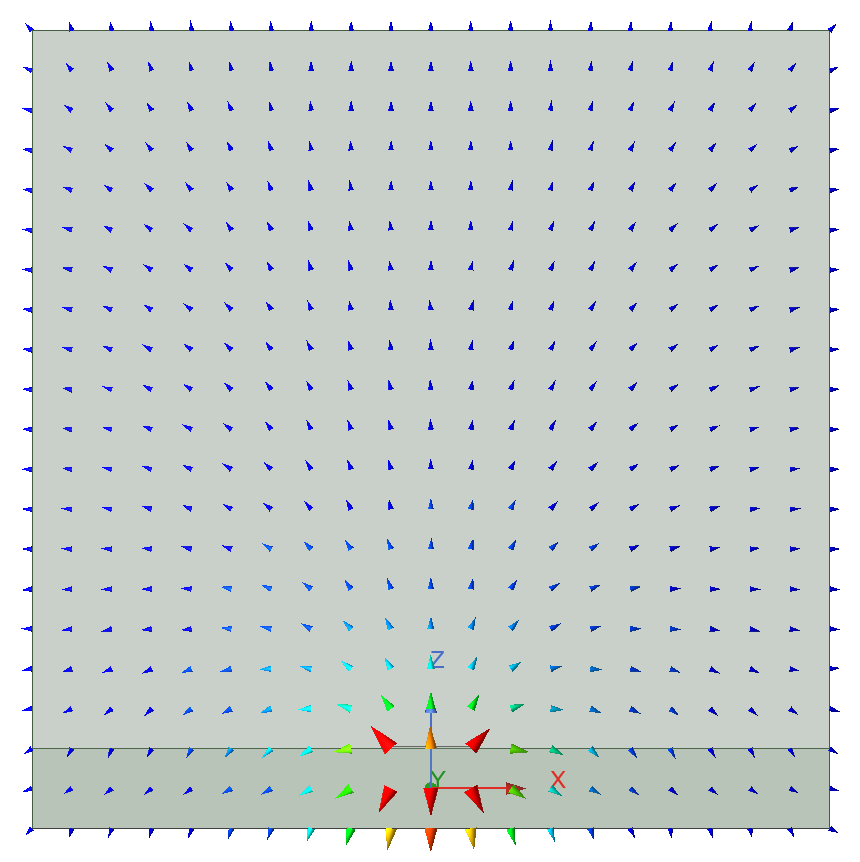

- w_line=0.03, h_subs=0.50

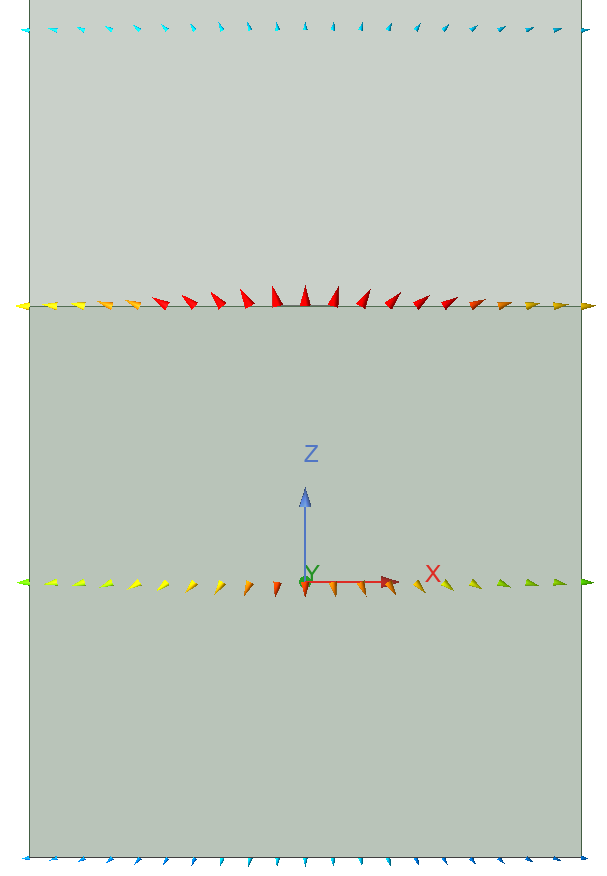

It is clearly observed that as h_subs increases the field couples more and more to the sidewalls. Therefore, for larger h_subs, I need to increase w_subs and w_port.

From plots of the ports field distribution not shown here:

For the largest w_line=0.2mm, it is noted that one does not need to increase much w_subs

The height of the wave port should be reduced for large h. In the highest part of the port there was coupling between the ports apparently.

### Dimension of h_port
For the largest h_subs, there is coupling between the ports. Thus, I'll reduce it to 4 x h_subs. Here I verify that for this h_port there is no coupling to the top wall of the wave port.

-w_line=0.05, h_subs=0.05

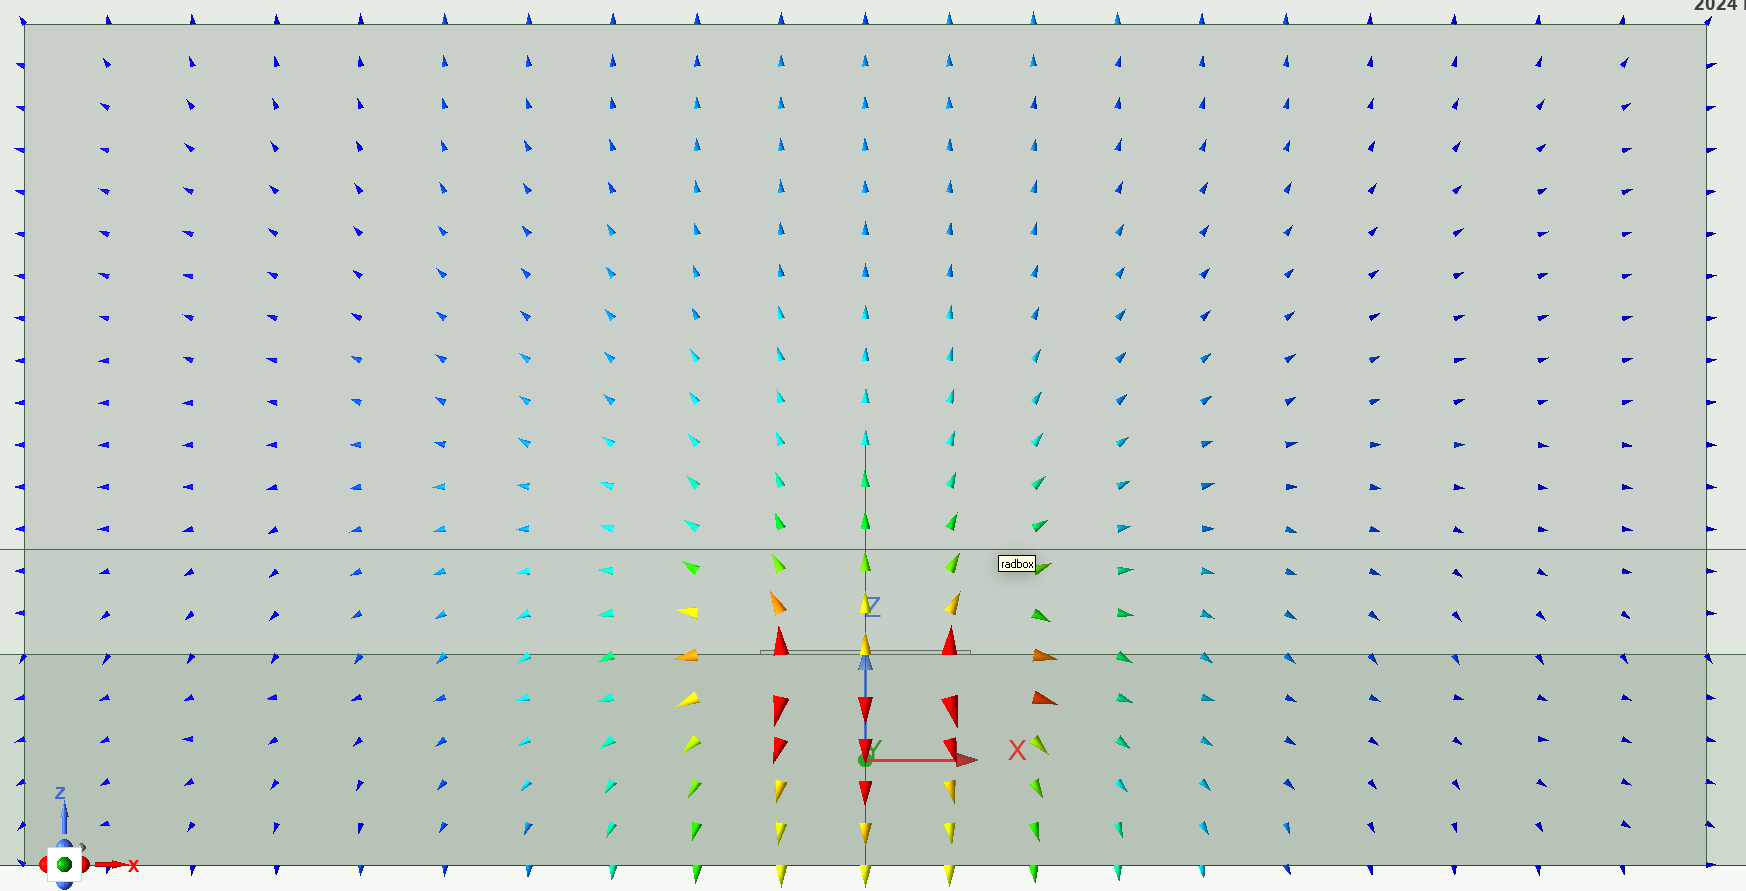

-w_line=0.05, h_subs=0.5

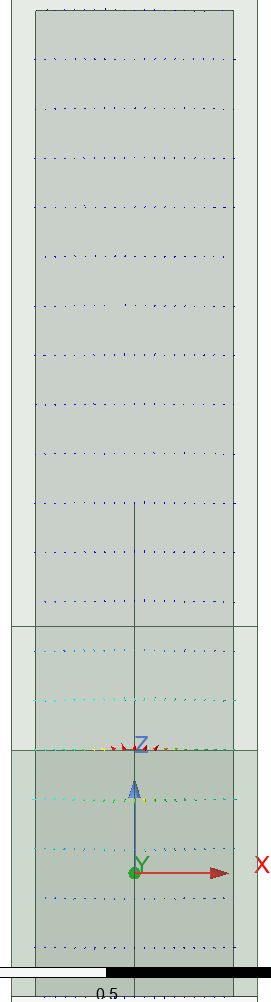

-w_line=0.2, h_subs=0.05

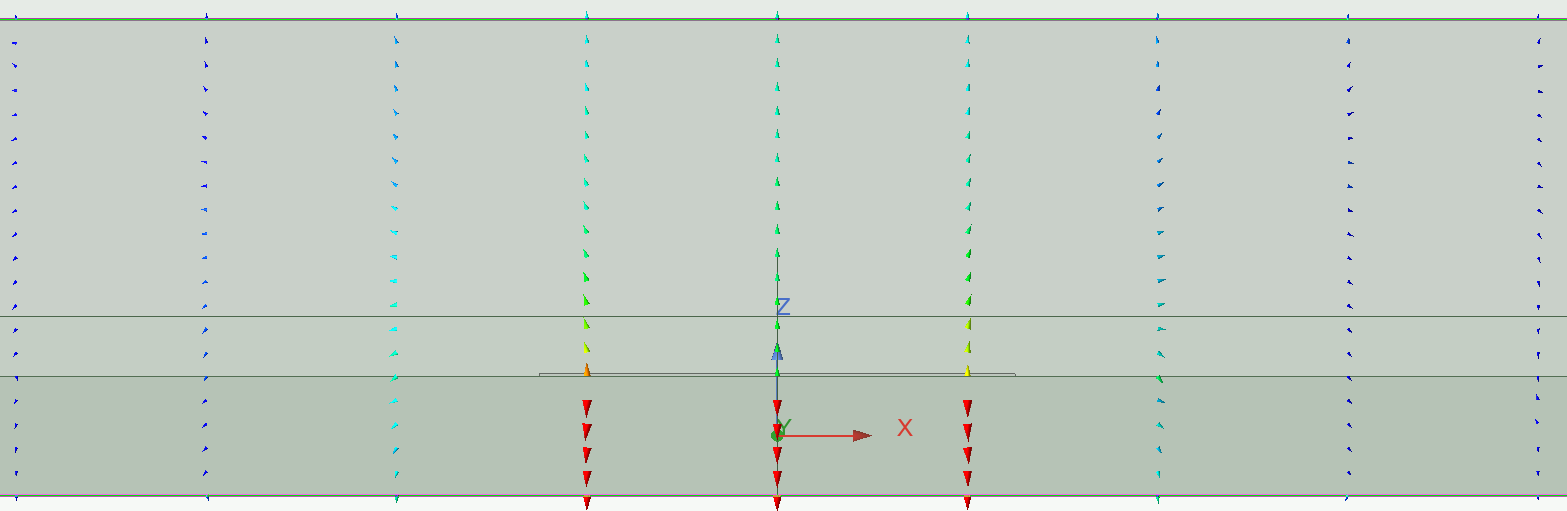

-w_line=0.2, h_subs=0.5

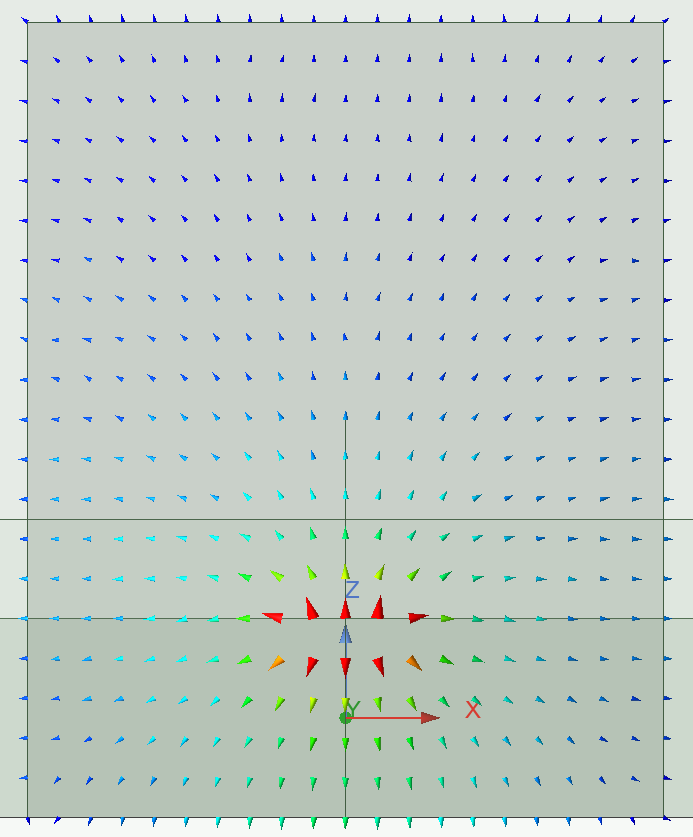

The smaller h_subs, the larger h_port needs to be relative to h_subs. 

The larger w_line, the larger h_port needs to be.

For the largest h_subs=0.5, h_port=hx4 is enough.

### First simulation with corrected wave port dimensions
- I choose w_subs = 50 x w to satisfy all cases.
- I choose h_port = 10 x h_subs for h_subs = 0.05, 0.1mm, and h_port = 4 x h_subs for h_subs = 0.2, 0.5mm.
- L is to be increased for h_subs = 0.2, 0.5, otherwise L = 2mm is comparable to h_port = 4 x h_subs = 0.8, 2mm. I choose L = 4mm for these h_subs.

The S11 parameter was still differing in several decades with the change of dimensions (w_line,h_subs).

1. The largest change in S11 corresponds to the case w_line=0.2, h_subs=0.05mm:

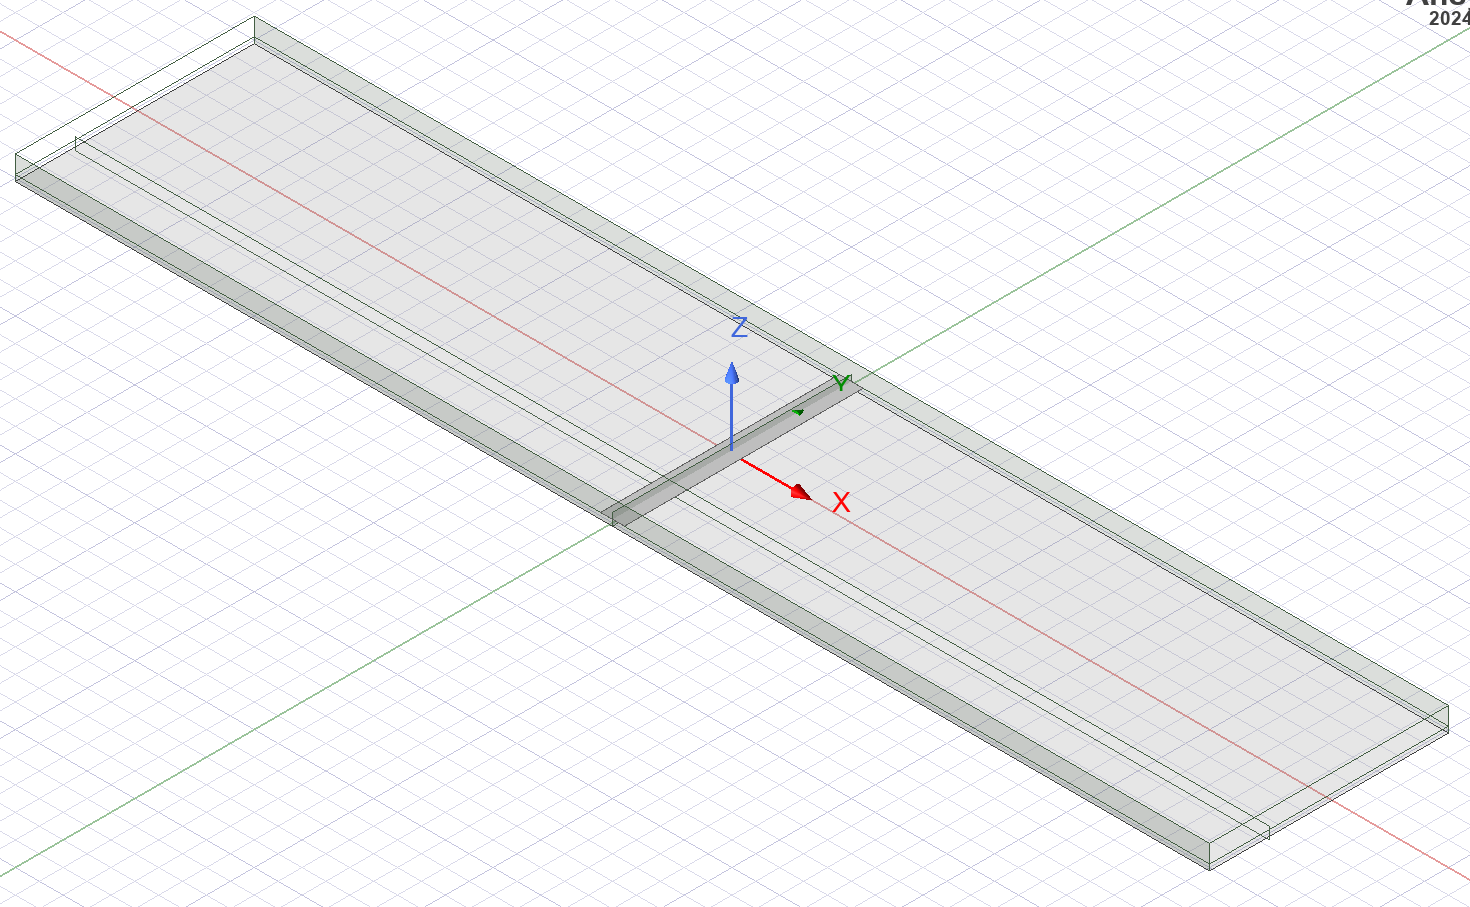

It is clear that relative to the other dimensions the width of the port is extremely large. I'll reduce it to w_port = 10 x w_line.

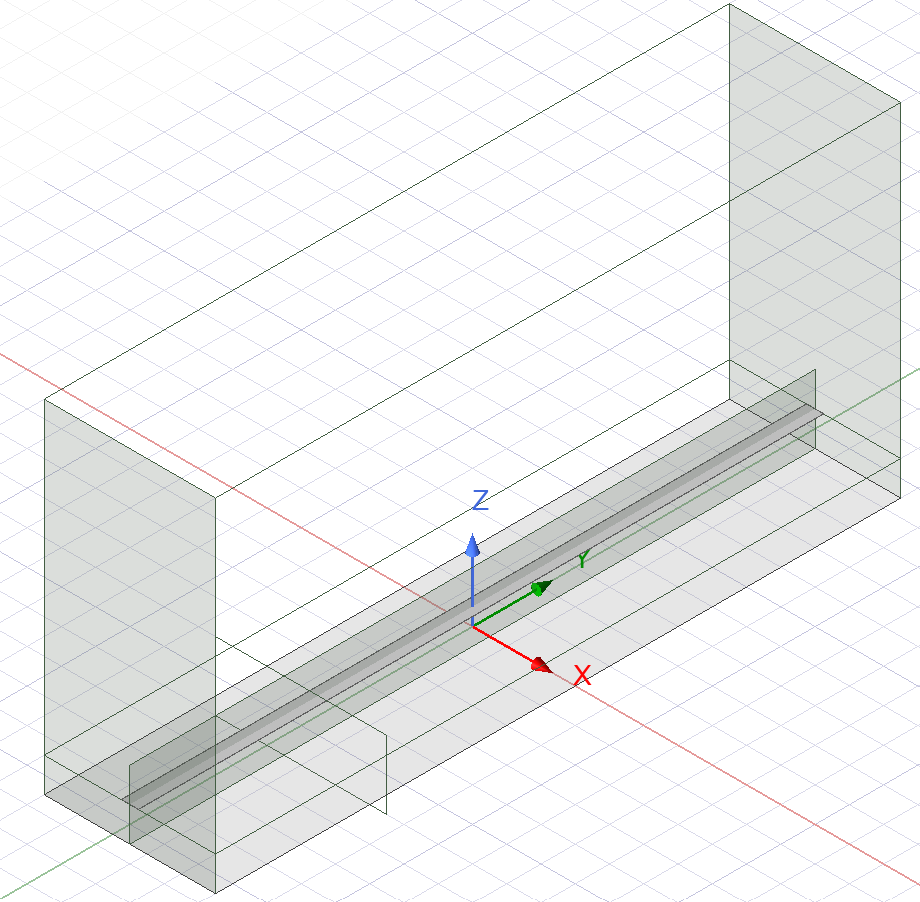

2. Regarding the case w_line=0.05, h_subs=0.1mm. Considering that h_port = 10 x h_subs = 1mm and L = 2mm. I'll increase L to 4mm for this h_subs.

For the largest h_subs = 0.2, 0.5mm, similar observations applied: some cases required to reduce w_port, or to increase L to 6 mm. 

Moreover, for w_line = 0.03mm and h_subs = 0.5mm, w_subs = 50 x w_line was not enough:

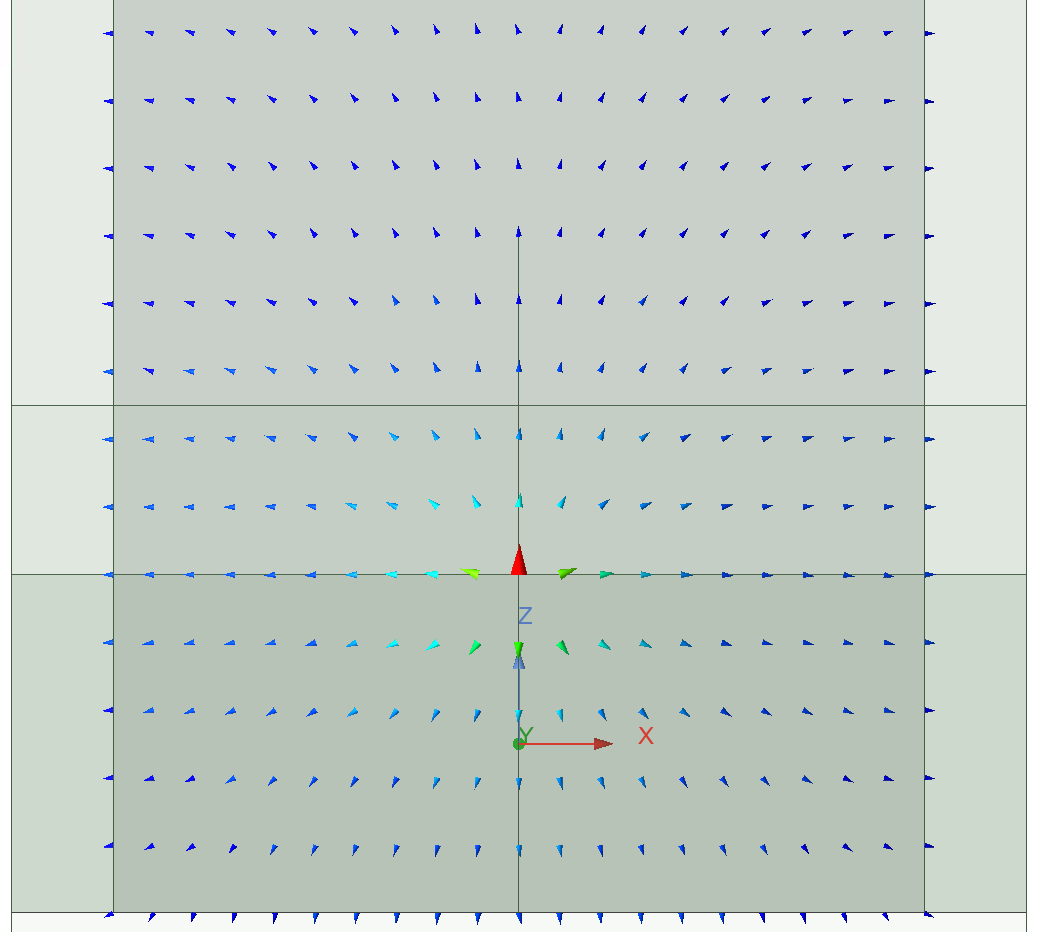

I increase w_subs to 100 x w_line for this case.

### Second corrections
1. S parameters are obtained:

Data extracted
Columns checked


C:\Users\mgomez\AppData\Local\Temp\ipykernel_21380\772500396.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][1].legend()
C:\Users\mgomez\AppData\Local\Temp\ipykernel_21380\772500396.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1][1].legend()


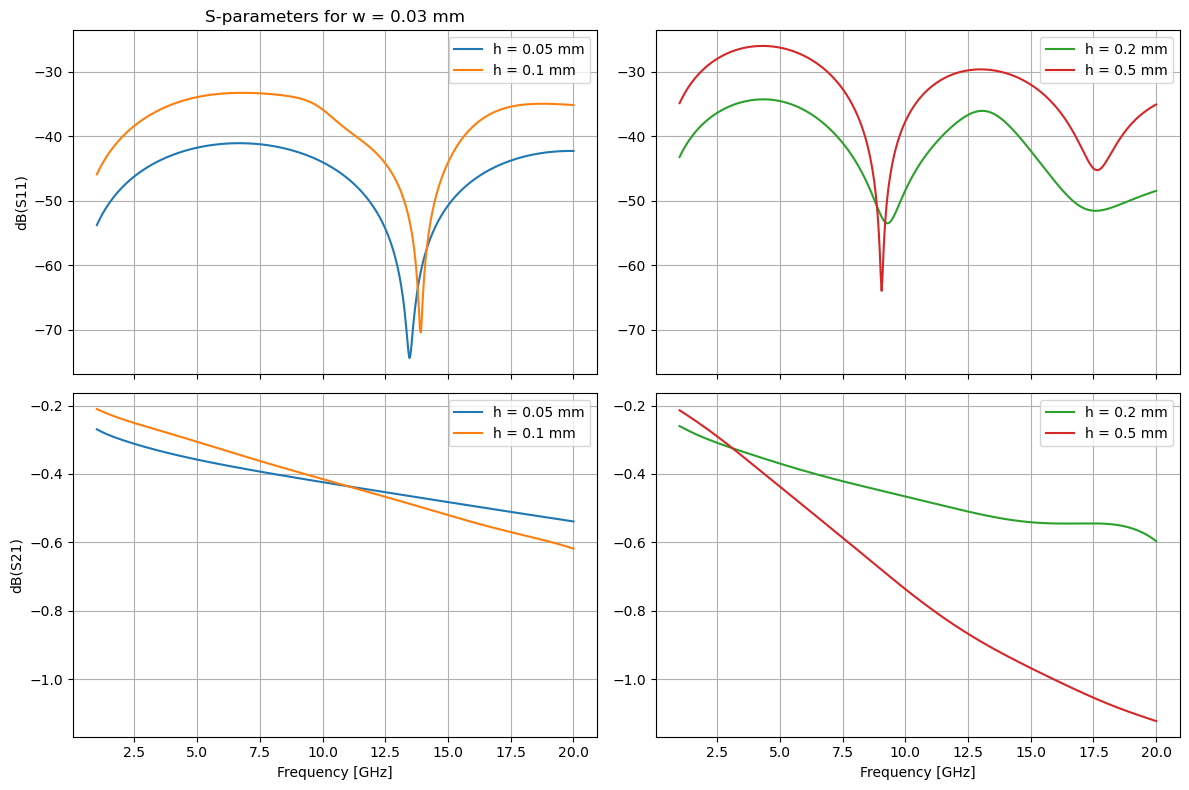

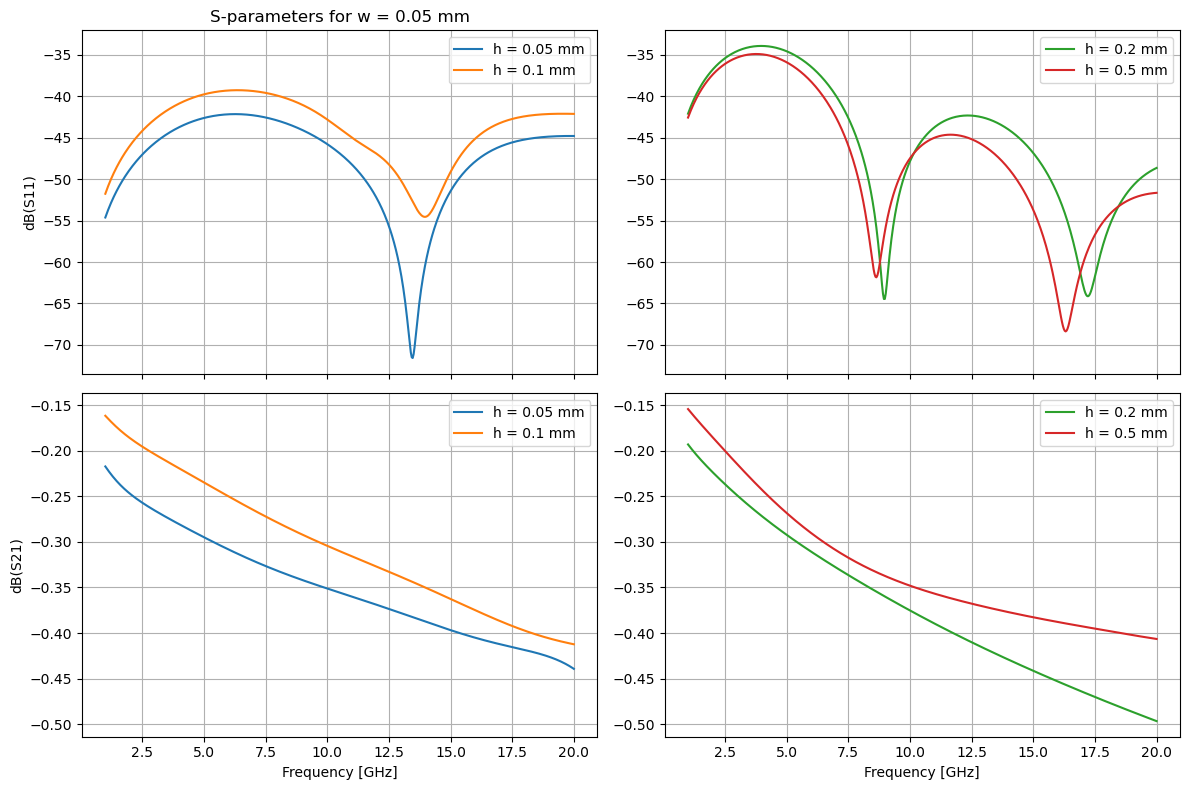

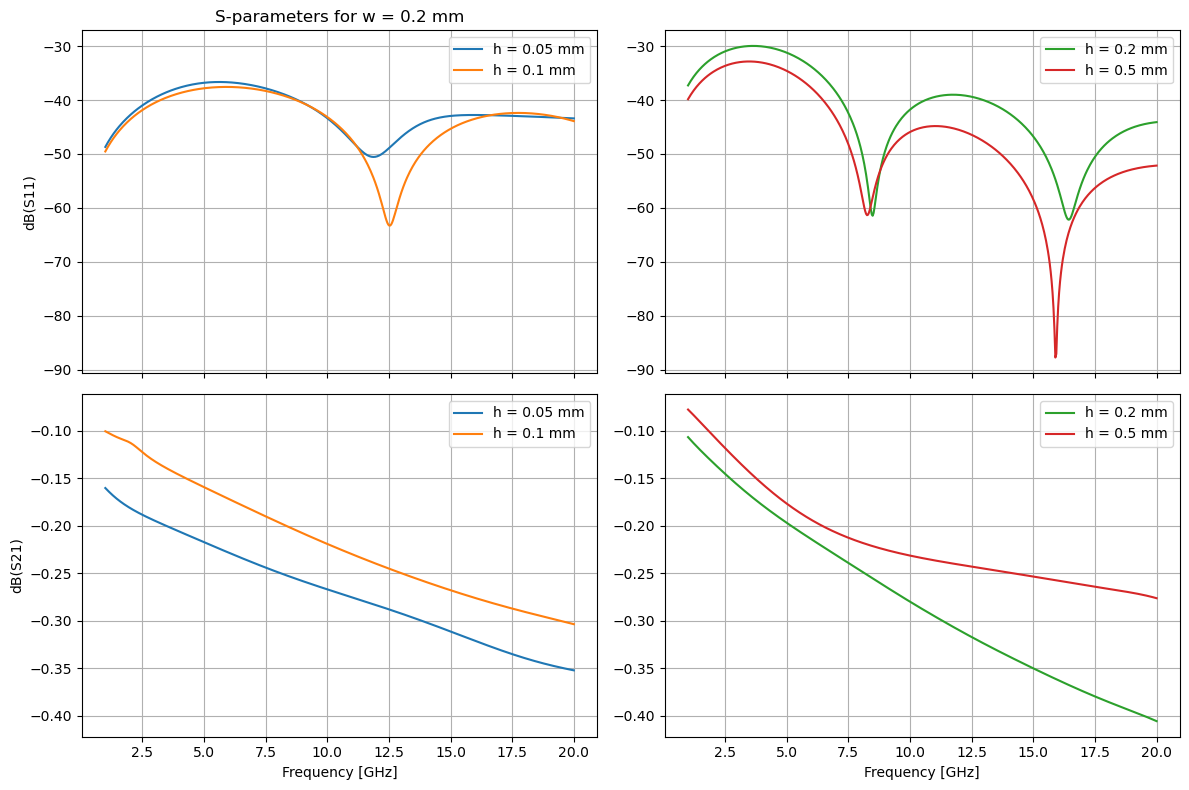

In [1]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

class HFSSPlotter:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.data = None

        self.col_h = "h [mm]"
        self.col_w = "w [mm]"
        self.col_freq = "Freq [GHz]"
        self.col_MagZo = "mag(Zo(Port_In)) []"
        self.col_s11 = "dB(S(Port_In,Port_In)) []"
        self.col_s21 = "dB(S(Port_Out,Port_In)) []"

    def load_data(self):
        self.data = pd.read_csv(self.csv_file)

    def check_columns(self):
        required_columns = [
            self.col_h,
            self.col_w,
            self.col_freq,
            self.col_MagZo,
            self.col_s11,
            self.col_s21,
        ]

        missing = [col for col in required_columns if col not in self.data.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

    def plot_for_each_w(self):
        unique_w_values = sorted(self.data[self.col_w].unique())
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        for w_value in unique_w_values:
            df_w = self.data[self.data[self.col_w] == w_value].copy()

            fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

            for h_ix, h_value in enumerate(sorted(df_w[self.col_h].unique())):
                df_wh = df_w[df_w[self.col_h] == h_value].copy()
                df_wh = df_wh.sort_values(by=self.col_freq)
                if h_value < 0.2:
                    axes[0][0].plot(
                        df_wh[self.col_freq],
                        df_wh[self.col_s11],
                        label=f"h = {h_value} mm",
                        c=colors[h_ix]
                    )
    
                    axes[1][0].plot(
                        df_wh[self.col_freq],
                        df_wh[self.col_s21],
                        label=f"h = {h_value} mm",
                        c=colors[h_ix]
                    )
                else:
                    axes[0][1].plot(
                        df_wh[self.col_freq],
                        df_wh[self.col_s11],
                        label=f"h = {h_value} mm",
                        c=colors[h_ix]
                    )
    
                    axes[1][1].plot(
                        df_wh[self.col_freq],
                        df_wh[self.col_s21],
                        label=f"h = {h_value} mm",
                        c=colors[h_ix]
                    )
                axes[0, 1].sharey(axes[0, 0])
                axes[0][0].set_ylabel("dB(S11)")
                axes[0][0].set_title(f"S-parameters for w = {w_value} mm")
                axes[0][0].grid(True)
                axes[0][0].legend()
                # axes[0][1].set_ylabel("dB(S11)")
                # axes[0][1].set_title(f"S-parameters for w = {w_value} mm")
                axes[0][1].grid(True)
                axes[0][1].legend()

                axes[1, 0].sharey(axes[1, 1])
                axes[1][0].set_xlabel("Frequency [GHz]")
                axes[1][0].set_ylabel("dB(S21)")
                axes[1][0].grid(True)
                axes[1][0].legend()
                axes[1][1].set_xlabel("Frequency [GHz]")
                # axes[1][1].set_ylabel("dB(S21)")
                axes[1][1].grid(True)
                axes[1][1].legend()
                
            plt.tight_layout()
            plt.show()

    def run(self):
        self.load_data()
        print("Data extracted")
        self.check_columns()
        print("Columns checked")
        self.plot_for_each_w()


if __name__ == "__main__":
    csv_file = "simus.csv"
    plotter = HFSSPlotter(csv_file)
    plotter.run()

The S parameters vary less than before with dimensions.

The resonance frequencies correspond to $\frac{\lambda_g}{2}$, which is expected for a microstrip with open circuit at both ends. For the larger h_subs = 0.2, 0.5mm, two resonance frequencies appear in contrast to only one for the smaller h_subs. This is because L is different for each case.

In [2]:
import pandas as pd
import numpy as np


class HFSSImpedanceTable:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.data = None

        self.col_h = "h [mm]"
        self.col_w = "w [mm]"
        self.col_freq = "Freq [GHz]"
        self.col_MagZo = "Mag(Zo) [Ohm]"
        self.col_ImZo = "Im(Zo) [Ohm]"

    def load_data(self):
        self.data = pd.read_csv(self.csv_file)
        self.data = self.data.rename(columns={
            "mag(Zo(Port_In)) []": "Mag(Zo) [Ohm]",
        })
    def check_columns(self):
        required_columns = [
            self.col_h,
            self.col_w,
            self.col_freq,
            self.col_MagZo,
        ]

        missing = [col for col in required_columns if col not in self.data.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

    def make_table_at_frequency(self, target_freq=9.4, tol=1e-2):
        # Keep only rows at the target frequency
        df = self.data[np.isclose(self.data[self.col_freq], target_freq, atol=tol)].copy()

        if df.empty:
            raise ValueError(f"No data found at {target_freq} GHz")

        # Compute magnitude of impedance if Re and Im are given
        # df["|Z| [Ohm]"] = np.sqrt(df[self.col_ReZo]**2 + df[self.col_ImZo]**2)

        # Keep only useful columns
        df = df[
            [
                self.col_w,       # leftmost column
                self.col_h,
                self.col_MagZo,
            ]
        ]

        # Sort rows by h first, then w
        df = df.sort_values(by=[self.col_w, self.col_h]).reset_index(drop=True)

        return df

    def run(self, target_freq=9.4):
        self.load_data()
        self.check_columns()
        table = self.make_table_at_frequency(target_freq)

        print(f"\nImpedance table at {target_freq} GHz:\n")
        print(table.to_string(index=False))

        return table


if __name__ == "__main__":
    csv_file = "simus.csv"
    hfss_table = HFSSImpedanceTable(csv_file)
    table = hfss_table.run(9.4)

    # Optional: save the table to a new CSV file
    # table.to_csv("impedance_table_9p4GHz.csv", index=False)


Impedance table at 9.4 GHz:

 w [mm]  h [mm]  Mag(Zo) [Ohm]
   0.03    0.05      55.845930
   0.03    0.10      71.423706
   0.03    0.20      86.754268
   0.03    0.50     105.955327
   0.05    0.05      44.629448
   0.05    0.10      60.144842
   0.05    0.20      73.983752
   0.05    0.50      95.380643
   0.20    0.05      18.934948
   0.20    0.10      30.399019
   0.20    0.20      43.738511
   0.20    0.50      63.647638


### Magnitude of Hx at 1/8 of the length L
$|H_x|$ is extracted from HFSS. 

We plot all the height of the substrate (z direction) but only a portion of the width (x direction). Thus we do not plot all the substrate width w_subs but only 5 x w_line

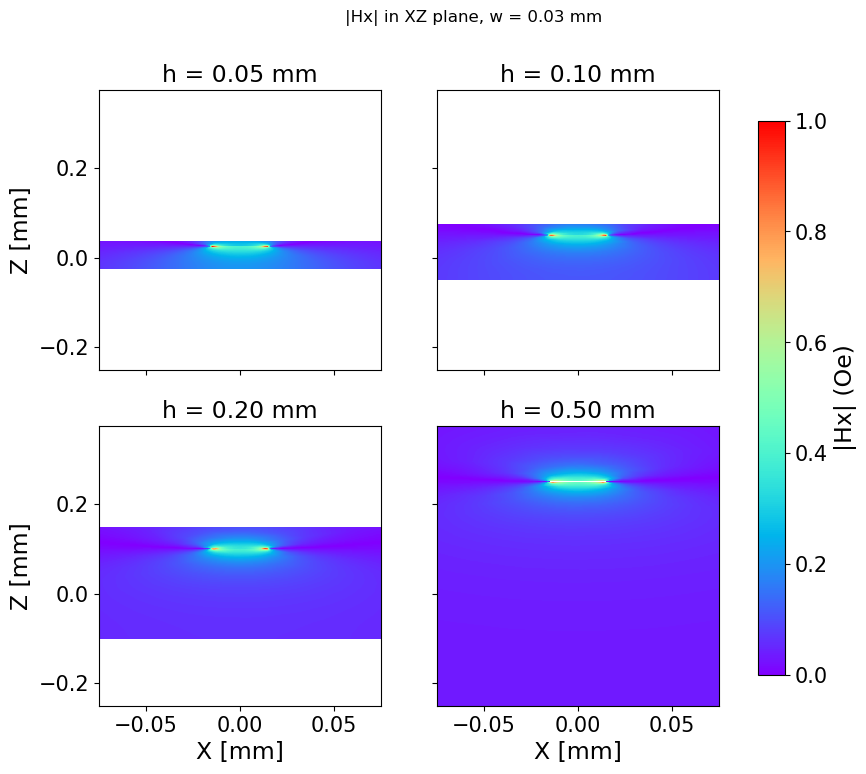

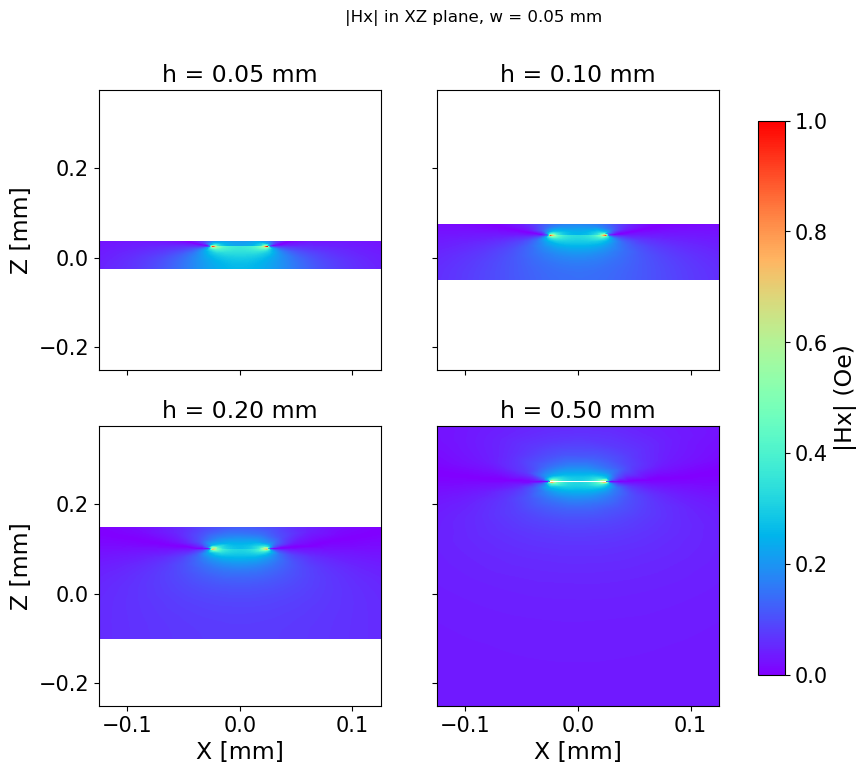

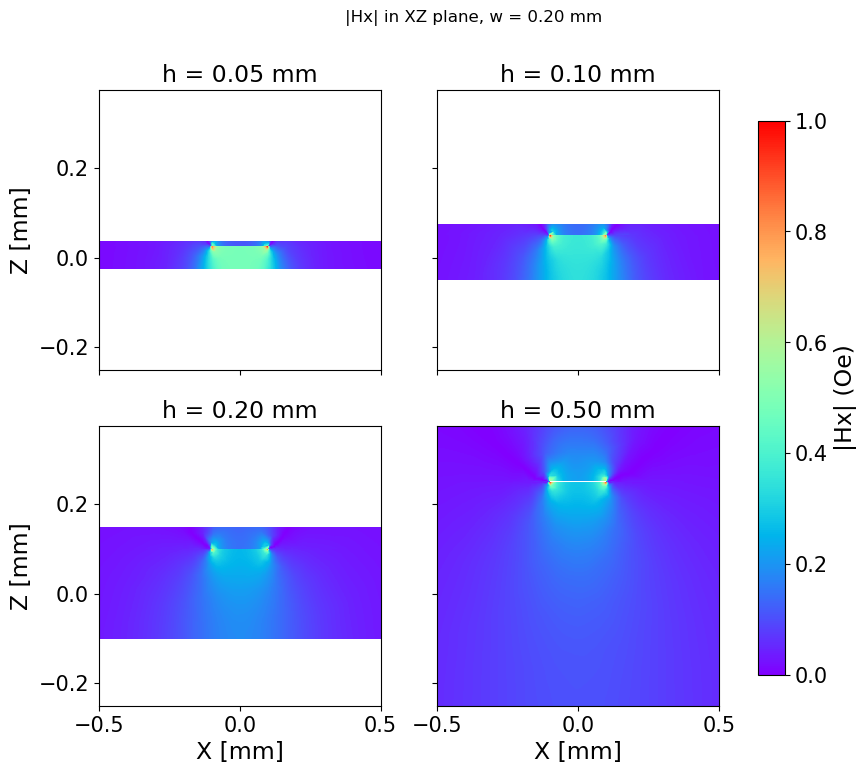

In [37]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def parse_filename(filepath):
    """
    Extract w and h from filenames like:
    Hx_p4_L6_w0.20_h0.50_pyaedt.fld
    """
    name = Path(filepath).name
    match = re.search(r"_w([0-9.]+)_h([0-9.]+)_pyaedt\.fld$", name)
    if not match:
        raise ValueError(f"Cannot read w and h from filename: {name}")
    w = float(match.group(1))
    h = float(match.group(2))
    return w, h


def load_hx_file(filename):
    """
    Load numeric data from the file.
    Assumes:
    - line 1: metadata
    - line 2: column names
    - line 3 onward: numeric data

    Expected columns:
    x, y, z, Hx
    """
    return np.loadtxt(filename, skiprows=2)


def build_xz_grid(data):
    """
    Build a 2D grid in the XZ plane using |Hx|.

    Assumes columns:
    data[:,0] -> x
    data[:,2] -> z
    data[:,3] -> Hx
    """
    x = data[:, 0]
    z = data[:, 2]
    hx = data[:, 3]

    hx_mag = np.abs(hx) * 4 * np.pi / 1000  # same conversion as your old code

    x_unique = np.unique(x)
    z_unique = np.unique(z)

    grid = np.full((len(z_unique), len(x_unique)), np.nan)

    x_index = {val: i for i, val in enumerate(x_unique)}
    z_index = {val: i for i, val in enumerate(z_unique)}

    for xi, zi, hi in zip(x, z, hx_mag):
        grid[z_index[zi], x_index[xi]] = hi

    return x_unique, z_unique, grid


def plot_all_by_w(folder=".",figname_prefix=""):
    folder = Path(folder)
    files = sorted(folder.glob("Hx_*_w*_h*_pyaedt.fld"))

    if not files:
        print("No matching files found.")
        return

    # Group files by w
    files_by_w = {}
    for f in files:
        w, h = parse_filename(f)
        files_by_w.setdefault(w, []).append((h, f))

    # One figure per w
    for w, h_files in sorted(files_by_w.items()):
        h_files = sorted(h_files, key=lambda t: t[0])  # sort by h

        # Load all 4 files first so that all subplots share the same color scale
        datasets = []
        vmax = 0.0

        for h, f in h_files:
            data = load_hx_file(f)
            x_unique, z_unique, grid = build_xz_grid(data)
            vmax = max(vmax, np.nanmax(grid))
            datasets.append((h, x_unique, z_unique, grid))

        fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
        axes = axes.ravel()

        mappable = None

        for i, (ax, (h, x_unique, z_unique, grid)) in enumerate(zip(axes, datasets)):
            pcm = ax.pcolormesh(
                x_unique * 1e3,   # m -> mm
                z_unique * 1e3,   # m -> mm
                grid/np.nanmax(grid),
                shading="auto",
                cmap="rainbow",
                vmin=0,
                vmax=np.nanmax(grid)/np.nanmax(grid)
            )
            mappable = pcm

            ax.set_title(f"h = {h:.2f} mm", fontsize=17)
            if i >= 2:
                ax.set_xlabel("X [mm]", fontsize=17)
            if i in (0, 2):
                ax.set_ylabel("Z [mm]", fontsize=17)
            ax.tick_params(axis='both', labelsize=15)

        # If fewer than 4 files exist for one w, hide unused axes
        for ax in axes[len(datasets):]:
            ax.axis("off")

        fig.suptitle(f"|Hx| in XZ plane, w = {w:.2f} mm")

        cbar = fig.colorbar(mappable, ax=axes, shrink=0.9)
        cbar.set_label("|Hx| (Oe)", fontsize=17)
        cbar.ax.tick_params(labelsize=15)


        #plt.tight_layout()
        figname = figname_prefix+f"_w{w:.2f}.png"
        plt.savefig(figname,dpi=300)
        plt.show()


if __name__ == "__main__":
    plot_all_by_w(".","Hx_normalized")

### Hx larger or equal to 1 Oe
Below only the region where $|H_x|\geq1$ Oe is plotted 

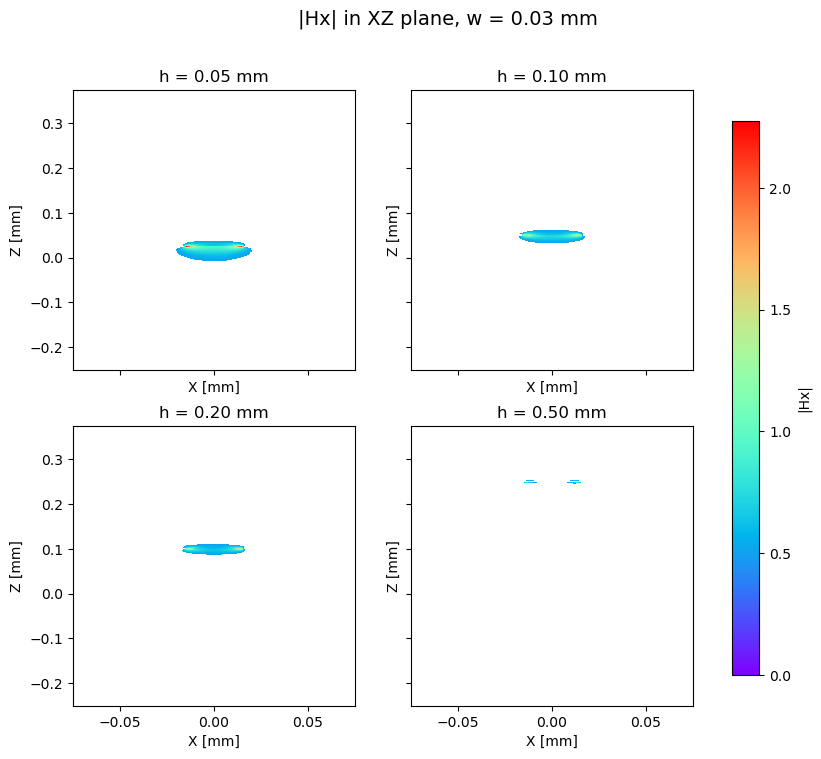

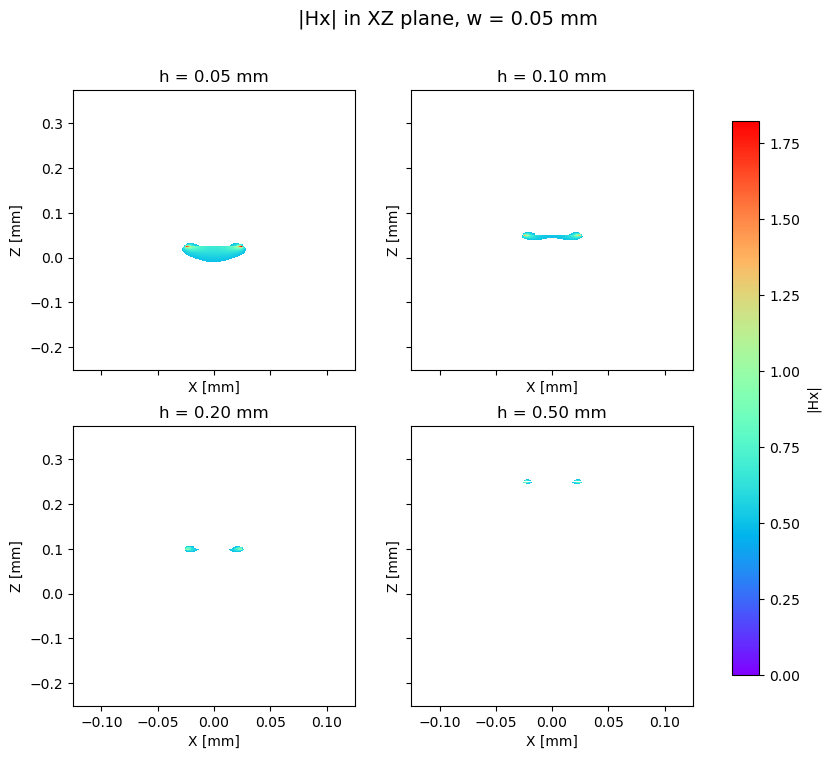

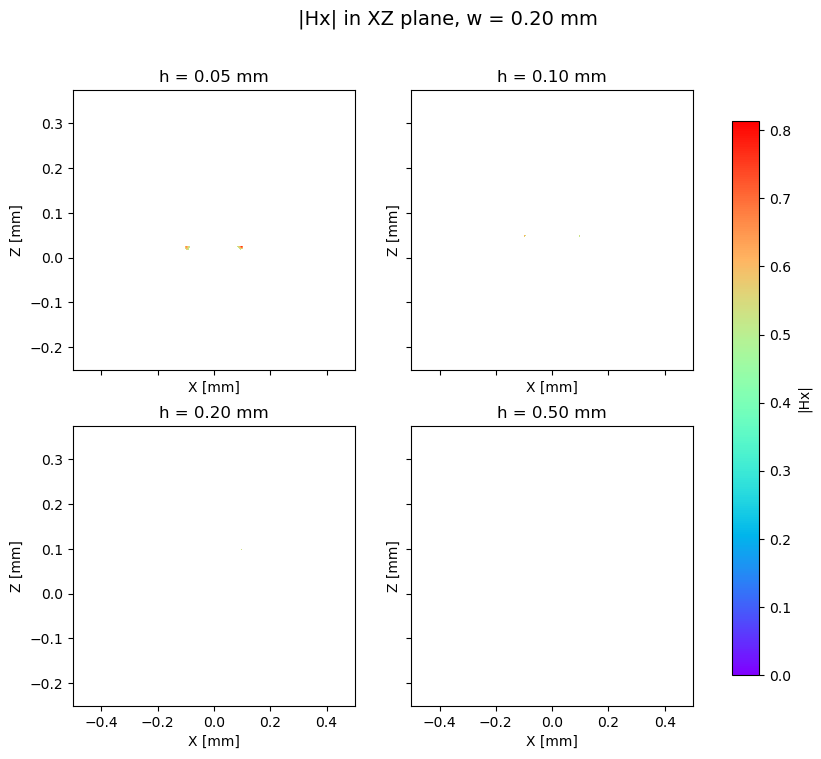

In [3]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def parse_filename(filepath):
    """
    Extract w and h from filenames like:
    Hx_p4_L6_w0.20_h0.50_pyaedt.fld
    """
    name = Path(filepath).name
    match = re.search(r"_w([0-9.]+)_h([0-9.]+)_pyaedt\.fld$", name)
    if not match:
        raise ValueError(f"Cannot read w and h from filename: {name}")
    w = float(match.group(1))
    h = float(match.group(2))
    return w, h


def load_hx_file(filename):
    """
    Load numeric data from the file.
    Assumes:
    - line 1: metadata
    - line 2: column names
    - line 3 onward: numeric data

    Expected columns:
    x, y, z, Hx
    """
    return np.loadtxt(filename, skiprows=2)


def build_xz_grid(data):
    """
    Build a 2D grid in the XZ plane using |Hx|.

    Assumes columns:
    data[:,0] -> x
    data[:,2] -> z
    data[:,3] -> Hx
    """
    x = data[:, 0]
    z = data[:, 2]
    hx = data[:, 3]

    hx_mag = np.abs(hx) * 4 * np.pi / 1000  # same conversion as your old code

    x_unique = np.unique(x)
    z_unique = np.unique(z)

    grid = np.full((len(z_unique), len(x_unique)), np.nan)

    x_index = {val: i for i, val in enumerate(x_unique)}
    z_index = {val: i for i, val in enumerate(z_unique)}

    for xi, zi, hi in zip(x, z, hx_mag):
        grid[z_index[zi], x_index[xi]] = hi

    return x_unique, z_unique, grid


def plot_all_by_w(folder=".",figname_prefix=""):
    folder = Path(folder)
    files = sorted(folder.glob("Hx_*_w*_h*_pyaedt.fld"))

    if not files:
        print("No matching files found.")
        return

    # Group files by w
    files_by_w = {}
    for f in files:
        w, h = parse_filename(f)
        files_by_w.setdefault(w, []).append((h, f))

    # One figure per w
    for w, h_files in sorted(files_by_w.items()):
        h_files = sorted(h_files, key=lambda t: t[0])  # sort by h

        # Load all 4 files first so that all subplots share the same color scale
        datasets = []
        vmax = 0.0

        for h, f in h_files:
            data = load_hx_file(f)
            x_unique, z_unique, grid = build_xz_grid(data)
            vmax = max(vmax, np.nanmax(grid))
            datasets.append((h, x_unique, z_unique, grid))

        fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
        axes = axes.ravel()

        mappable = None

        for ax, (h, x_unique, z_unique, grid) in zip(axes, datasets):
            grid[grid<0.5]=np.nan
            pcm = ax.pcolormesh(
                x_unique * 1e3,   # m -> mm
                z_unique * 1e3,   # m -> mm
                grid,
                shading="auto",
                cmap="rainbow",
                vmin=0,
                vmax=vmax
            )
            mappable = pcm

            ax.set_title(f"h = {h:.2f} mm")
            ax.set_xlabel("X [mm]")
            ax.set_ylabel("Z [mm]")

        # If fewer than 4 files exist for one w, hide unused axes
        for ax in axes[len(datasets):]:
            ax.axis("off")

        fig.suptitle(f"|Hx| in XZ plane, w = {w:.2f} mm", fontsize=14)

        cbar = fig.colorbar(mappable, ax=axes, shrink=0.9)
        cbar.set_label("|Hx|")

        #plt.tight_layout()
        figname = figname_prefix+f"_w{w:.2f}.png"
        plt.savefig(figname,dpi=300)
        plt.show()


if __name__ == "__main__":
    plot_all_by_w(".","Hx_1_Oe")

Global color scale: vmin = 0.0, vmax = 2.2759467990121727


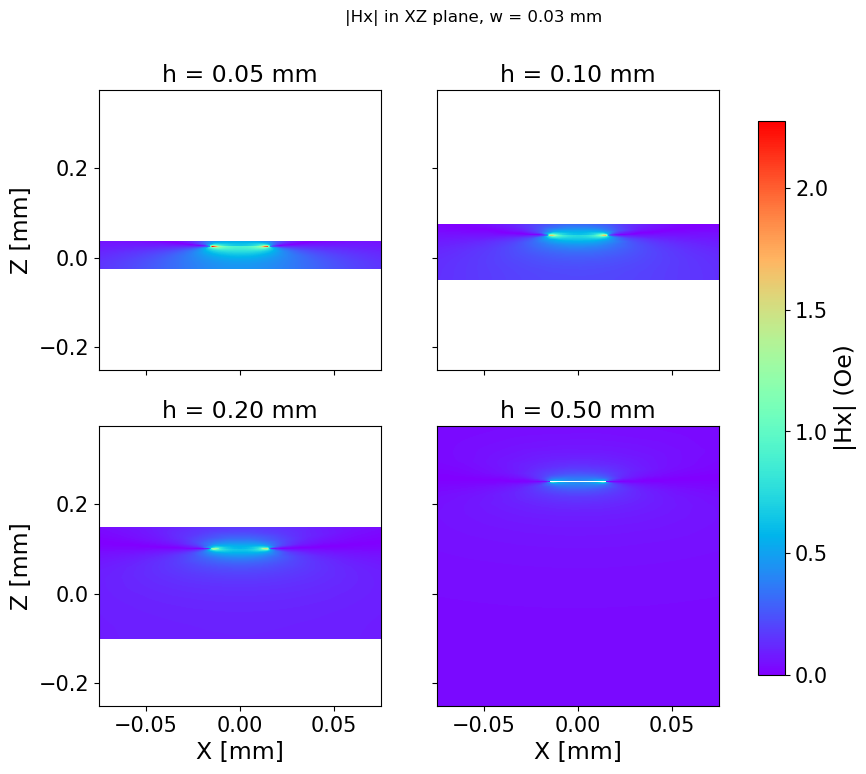

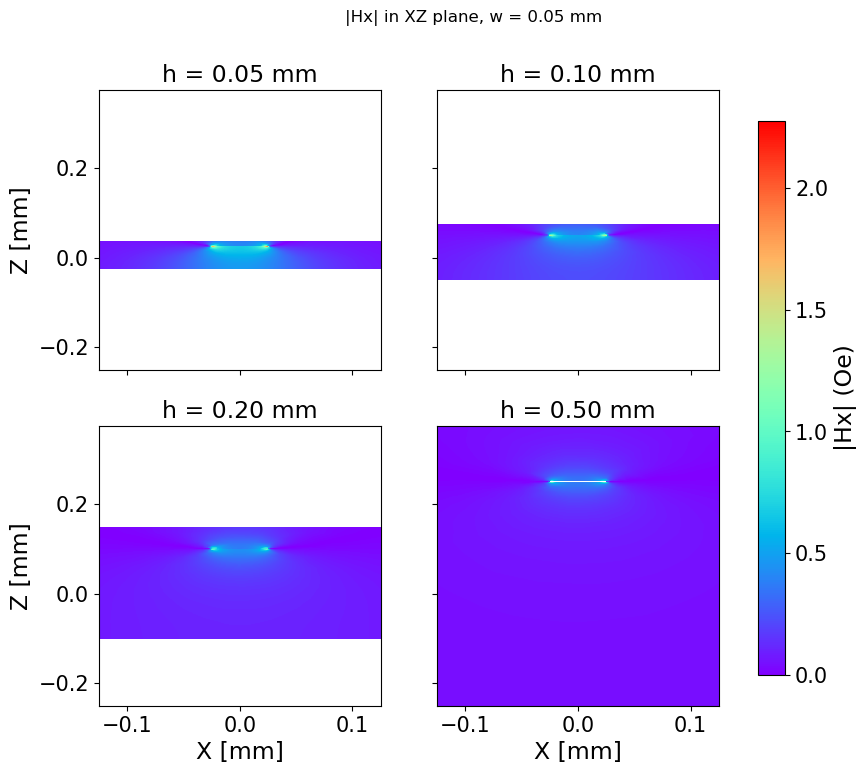

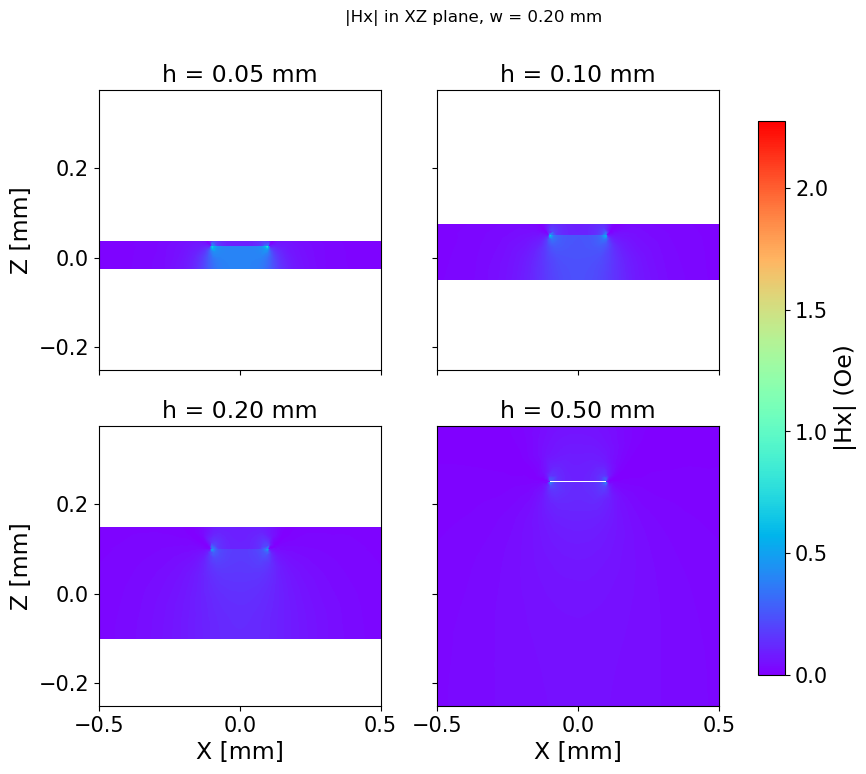

In [11]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def parse_filename(filepath):
    """
    Extract w and h from filenames like:
    Hx_p4_L6_w0.20_h0.50_pyaedt.fld
    """
    name = Path(filepath).name
    match = re.search(r"_w([0-9.]+)_h([0-9.]+)_pyaedt\.fld$", name)
    if not match:
        raise ValueError(f"Cannot read w and h from filename: {name}")
    w = float(match.group(1))
    h = float(match.group(2))
    return w, h


def load_hx_file(filename):
    """
    Load numeric data from the file.
    Assumes:
    - line 1: metadata
    - line 2: column names
    - line 3 onward: numeric data

    Expected columns:
    x, y, z, Hx
    """
    return np.loadtxt(filename, skiprows=2)


def build_xz_grid(data):
    """
    Build a 2D grid in the XZ plane using |Hx|.

    Assumes columns:
    data[:,0] -> x
    data[:,2] -> z
    data[:,3] -> Hx
    """
    x = data[:, 0]
    z = data[:, 2]
    hx = data[:, 3]

    hx_mag = np.abs(hx) * 4 * np.pi / 1000

    x_unique = np.unique(x)
    z_unique = np.unique(z)

    grid = np.full((len(z_unique), len(x_unique)), np.nan)

    x_index = {val: i for i, val in enumerate(x_unique)}
    z_index = {val: i for i, val in enumerate(z_unique)}

    for xi, zi, hi in zip(x, z, hx_mag):
        grid[z_index[zi], x_index[xi]] = hi

    return x_unique, z_unique, grid


def plot_all_by_w(folder=".",figname_prefix=""):
    folder = Path(folder)
    files = sorted(folder.glob("Hx_*_w*_h*_pyaedt.fld"))

    if not files:
        print("No matching files found.")
        return

    # Group files by w
    files_by_w = {}
    for f in files:
        w, h = parse_filename(f)
        files_by_w.setdefault(w, []).append((h, f))

    # ------------------------------------------------------------------
    # FIRST PASS: load everything and compute one global color scale
    # ------------------------------------------------------------------
    all_datasets_by_w = {}
    global_vmin = np.inf
    global_vmax = -np.inf

    for w, h_files in sorted(files_by_w.items()):
        h_files = sorted(h_files, key=lambda t: t[0])

        datasets = []
        for h, f in h_files:
            data = load_hx_file(f)
            x_unique, z_unique, grid = build_xz_grid(data)

            local_min = np.nanmin(grid)
            local_max = np.nanmax(grid)

            global_vmin = min(global_vmin, local_min)
            global_vmax = max(global_vmax, local_max)

            datasets.append((h, x_unique, z_unique, grid))

        all_datasets_by_w[w] = datasets

    # Since you are plotting |Hx|, forcing vmin=0 often makes sense
    global_vmin = 0.0

    print(f"Global color scale: vmin = {global_vmin}, vmax = {global_vmax}")

    # ------------------------------------------------------------------
    # SECOND PASS: plot each figure using the same vmin/vmax
    # ------------------------------------------------------------------
    for w, datasets in sorted(all_datasets_by_w.items()):
        fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
        axes = axes.ravel()
        mappable = None

        for i, (ax, (h, x_unique, z_unique, grid)) in enumerate(zip(axes, datasets)):
            pcm = ax.pcolormesh(
                x_unique * 1e3,   # m -> mm
                z_unique * 1e3,   # m -> mm
                grid,
                shading="auto",
                cmap="rainbow",
                vmin=global_vmin,
                vmax=global_vmax
            )
            mappable = pcm

            ax.set_title(f"h = {h:.2f} mm", fontsize=17)
            if i >= 2:
                ax.set_xlabel("X [mm]", fontsize=17)
            if (i==0) | (i==2):
                ax.set_ylabel("Z [mm]",fontsize=17)
            ax.tick_params(axis='both', labelsize=15)
            
        # Hide unused axes if fewer than 4 files
        for ax in axes[len(datasets):]:
            ax.axis("off")

        fig.suptitle(f"|Hx| in XZ plane, w = {w:.2f} mm")

        cbar = fig.colorbar(mappable, ax=axes, shrink=0.9)
        cbar.set_label("|Hx| (Oe)", fontsize=17)
        cbar.ax.tick_params(labelsize=15)
        figname = figname_prefix+f"_w{w:.2f}.png"
        plt.savefig(figname,dpi=300)
        plt.show()


if __name__ == "__main__":
    plot_all_by_w(".","Hx_shared cbar")

Global grad color scale: vmin = 0.0, vmax = 120.67762242389102


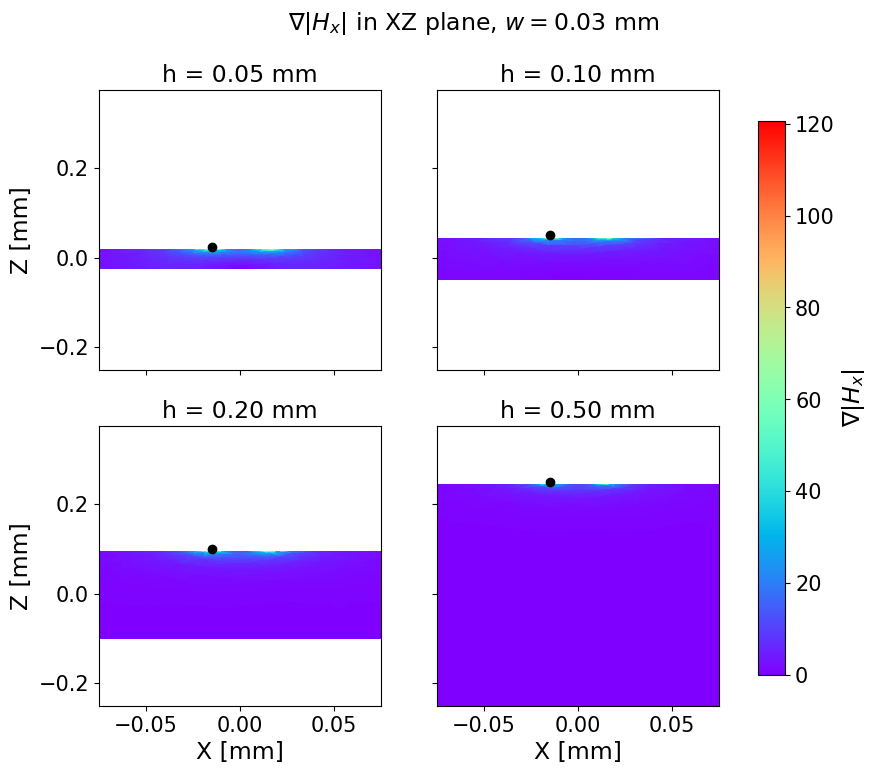

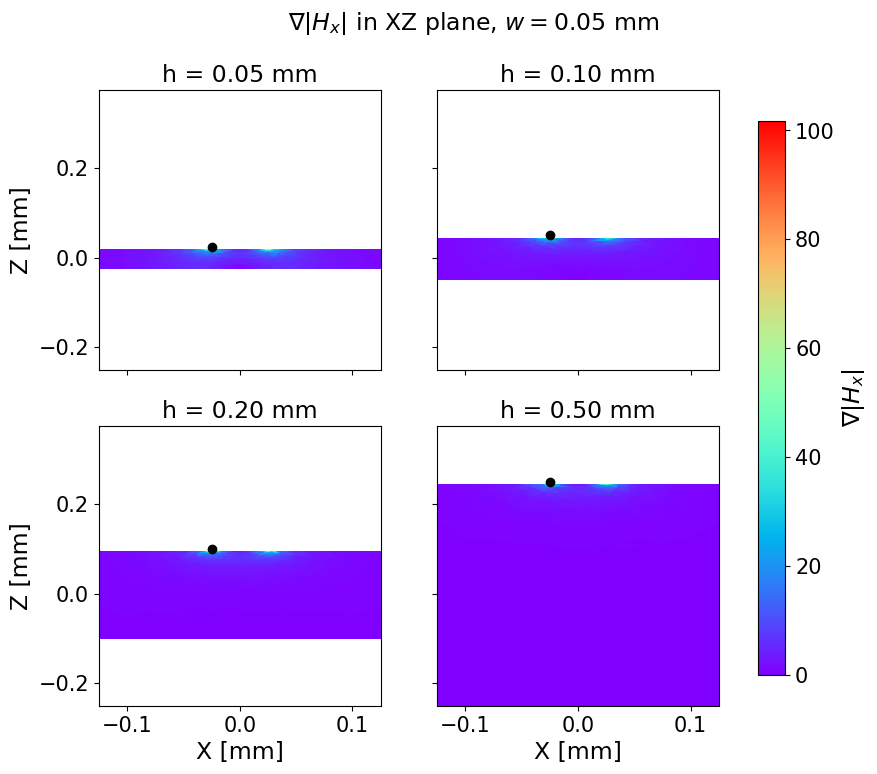

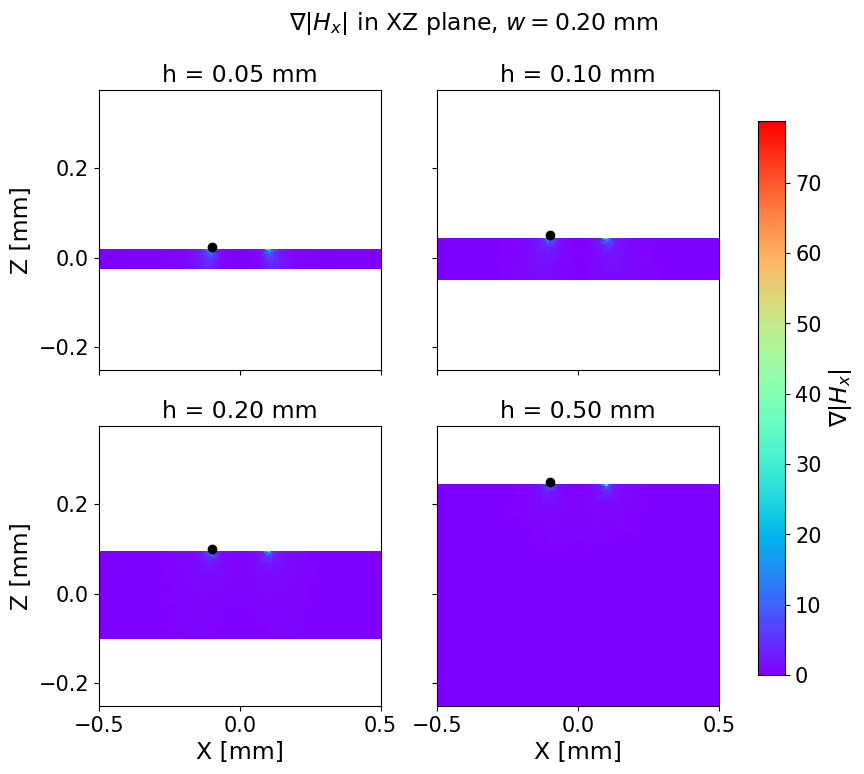

In [33]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Choose color scale behavior here
# True  -> all figures share the same color scale
# False -> each figure has its own color scale
# ------------------------------------------------------------------
USE_GLOBAL_COLOR_SCALE = False


def parse_filename(filepath):
    """
    Extract w and h from filenames like:
    Hx_p4_L6_w0.20_h0.50_pyaedt.fld
    """
    name = Path(filepath).name
    match = re.search(r"_w([0-9.]+)_h([0-9.]+)_pyaedt\.fld$", name)
    if not match:
        raise ValueError(f"Cannot read w and h from filename: {name}")
    w = float(match.group(1))
    h = float(match.group(2))
    return w, h


def load_hx_file(filename):
    """
    Load numeric data from the file.
    Assumes:
    - line 1: metadata
    - line 2: column names
    - line 3 onward: numeric data

    Expected columns:
    x, y, z, Hx
    """
    return np.loadtxt(filename, skiprows=2)


def build_xz_grid(data):
    """
    Build a 2D grid in the XZ plane using |Hx|.

    Assumes columns:
    data[:,0] -> x
    data[:,2] -> z
    data[:,3] -> Hx
    """
    x = data[:, 0]
    z = data[:, 2]
    hx = data[:, 3]

    hx_mag = np.abs(hx) * 4 * np.pi / 1000

    x_unique = np.unique(x)
    z_unique = np.unique(z)

    grid = np.full((len(z_unique), len(x_unique)), np.nan)

    x_index = {val: i for i, val in enumerate(x_unique)}
    z_index = {val: i for i, val in enumerate(z_unique)}

    for xi, zi, hi in zip(x, z, hx_mag):
        grid[z_index[zi], x_index[xi]] = hi

    return x_unique, z_unique, grid


def compute_gradient_safe(x_unique, z_unique, grid):
    """
    Compute gradient of the scalar field grid robustly.

    Returns:
        dHx_dx, dHx_dz, grad_mag
    """
    dx = np.diff(x_unique) * 1e3
    dz = np.diff(z_unique) * 1e3

    if len(dx) == 0 or len(dz) == 0:
        raise ValueError("Grid must contain at least two unique x values and two unique z values.")

    if np.any(dx == 0) or np.any(dz == 0):
        raise ValueError("Duplicate coordinates detected: zero spacing in x or z.")

    dx_mean = np.mean(dx)
    dz_mean = np.mean(dz)

    grid_clean = np.array(grid, dtype=float, copy=True)
    nan_mask = np.isnan(grid_clean)

    # Fill NaNs temporarily to avoid propagation in np.gradient
    grid_clean[nan_mask] = 0.0

    with np.errstate(divide="ignore", invalid="ignore"):
        dHx_dz, dHx_dx = np.gradient(grid_clean, dz_mean, dx_mean)

    dHx_dx[nan_mask] = np.nan
    dHx_dz[nan_mask] = np.nan

    grad_mag = np.sqrt(dHx_dx**2 + dHx_dz**2)

    return dHx_dx, dHx_dz, grad_mag


def mask_gradient_region(x_unique, z_unique, grad_mag, w, h):
    """
    Mask grad_mag in a selected region.

    Here w and h are assumed to be in mm (from filename),
    while x_unique and z_unique are in meters.
    """
    x_mm = x_unique * 1e3
    z_mm = z_unique * 1e3

    X_mm, Z_mm = np.meshgrid(x_mm, z_mm)

    region_mask = (
        (Z_mm >= h / 2 - 0.005)
        # Example of a more restrictive mask:
        # (X_mm >= -w / 2) & (X_mm <= w / 2) &
        # (Z_mm >= h / 2) & (Z_mm <= (h / 2 + 0.001))
    )

    grad_mag_masked = grad_mag.copy()
    grad_mag_masked[region_mask] = np.nan

    return grad_mag_masked


def plot_all_by_w(folder=".", figname_prefix="", use_global_color_scale=True):
    folder = Path(folder)
    files = sorted(folder.glob("Hx_*_w*_h*_pyaedt.fld"))

    if not files:
        print("No matching files found.")
        return

    # Group files by w
    files_by_w = {}
    for f in files:
        w, h = parse_filename(f)
        files_by_w.setdefault(w, []).append((h, f))

    # ------------------------------------------------------------------
    # FIRST PASS: load everything
    # Also compute:
    # - global color scale
    # - per-figure color scale
    # ------------------------------------------------------------------
    all_grads_by_w = {}

    global_vmin_grad = 0.0
    global_vmax_grad = -np.inf

    for w, h_files in sorted(files_by_w.items()):
        h_files = sorted(h_files, key=lambda t: t[0])

        grads = []
        local_vmax_grad = -np.inf

        for h, f in h_files:
            data = load_hx_file(f)
            x_unique, z_unique, grid = build_xz_grid(data)

            dHx_dx, dHx_dz, grad_mag = compute_gradient_safe(x_unique, z_unique, grid)
            grad_mag = mask_gradient_region(x_unique, z_unique, grad_mag, w, h)

            this_vmax = np.nanmax(grad_mag)
            local_vmax_grad = max(local_vmax_grad, this_vmax)
            global_vmax_grad = max(global_vmax_grad, this_vmax)

            grads.append((h, x_unique, z_unique, grad_mag))

        # store both the data and that figure's own vmax
        all_grads_by_w[w] = {
            "grads": grads,
            "local_vmin_grad": 0.0,
            "local_vmax_grad": local_vmax_grad
        }

    print(f"Global grad color scale: vmin = {global_vmin_grad}, vmax = {global_vmax_grad}")

    # ------------------------------------------------------------------
    # SECOND PASS: plot
    # ------------------------------------------------------------------
    for w, data_dict in sorted(all_grads_by_w.items()):
        grads = data_dict["grads"]
        local_vmin_grad = data_dict["local_vmin_grad"]
        local_vmax_grad = data_dict["local_vmax_grad"]

        if use_global_color_scale:
            vmin_plot = global_vmin_grad
            vmax_plot = global_vmax_grad
        else:
            vmin_plot = local_vmin_grad
            vmax_plot = local_vmax_grad

        fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
        axes2 = axes2.ravel()

        cmap = plt.cm.rainbow.copy()
        cmap.set_bad(color="white")

        mappable = None

        for i, (ax, (h, x_unique, z_unique, grad_mag)) in enumerate(zip(axes2, grads)):
            grad_plot = np.ma.masked_invalid(grad_mag)

            pcm = ax.pcolormesh(
                x_unique * 1e3,   # m -> mm
                z_unique * 1e3,   # m -> mm
                grad_plot,
                shading="auto",
                cmap=cmap,
                vmin=vmin_plot,
                vmax=vmax_plot
            )
            mappable = pcm

            ax.set_title(f"h = {h:.2f} mm", fontsize=17)
            if i >= 2:
                ax.set_xlabel("X [mm]", fontsize=17)
            if i in (0, 2):
                ax.set_ylabel("Z [mm]", fontsize=17)
            ax.tick_params(axis='both', labelsize=15)

        # Hide unused axes if fewer than 4 files
        for ax in axes2[len(grads):]:
            ax.axis("off")

        fig2.suptitle(rf"$\nabla |H_x|$ in XZ plane, $w = {w:.2f}$ mm", fontsize=17)

        cbar2 = fig2.colorbar(mappable, ax=axes2, shrink=0.9)
        cbar2.set_label(r"$\nabla |H_x|$", fontsize=17)
        cbar2.ax.tick_params(labelsize=15)

        scale_tag = "_global" if use_global_color_scale else "_local"
        figname = f"{figname_prefix}_w{w:.2f}{scale_tag}.png"
        plt.savefig(figname, dpi=300)
        plt.show()


if __name__ == "__main__":
    plot_all_by_w(
        folder=".",
        figname_prefix="Hx_gradient",
        use_global_color_scale=USE_GLOBAL_COLOR_SCALE
    )

## Paper #1
**Title:** Coupling Electromagnetic Waves to Spin Waves: A Physics-Based Nonlinear Circuit Model for Frequency-Selective Limiters

**Year:** 2019

A physics-based nonlinear circuit model (for ADS) is developed and validated experimentally for frequency-selective limiters (FSLs) based on thin-film magnetic materials. 

FSL used in this work (parallel pumping):

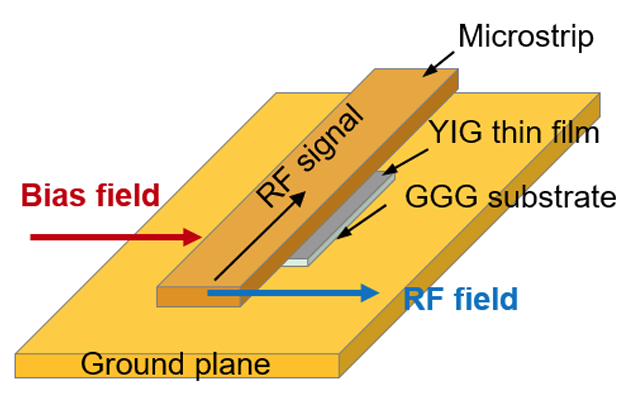

The spin motions as well as the ferromagnetic resonance (FMR) are modeled by RLC parallel circuits with parameters derived from Polder’s tensor and Kittel’s equations.

### Modelling
1. **Spin motion: RLC circuit equivalent**

LLG equation --> Linearization around the direction of $H_0$ --> resonance frequency, impedance of magnetic film

--> equivalence to RLC circuit impedance --> Find corresponding values for R, L, C

2. **Exchange interaction between spins: coupling inductor $L_c$**

Linearized LLG equation --> dispersion relation --> equivalence to dispersion relation for RLC circuit + coupling inductor

3. **Coupling EM waves to spin waves**

How do they link EM and spintronics? They model that interaction through an equivalent pendulum system, which has en equivalent nonlinear circuit consisting of two resonators with their inductors coupled.

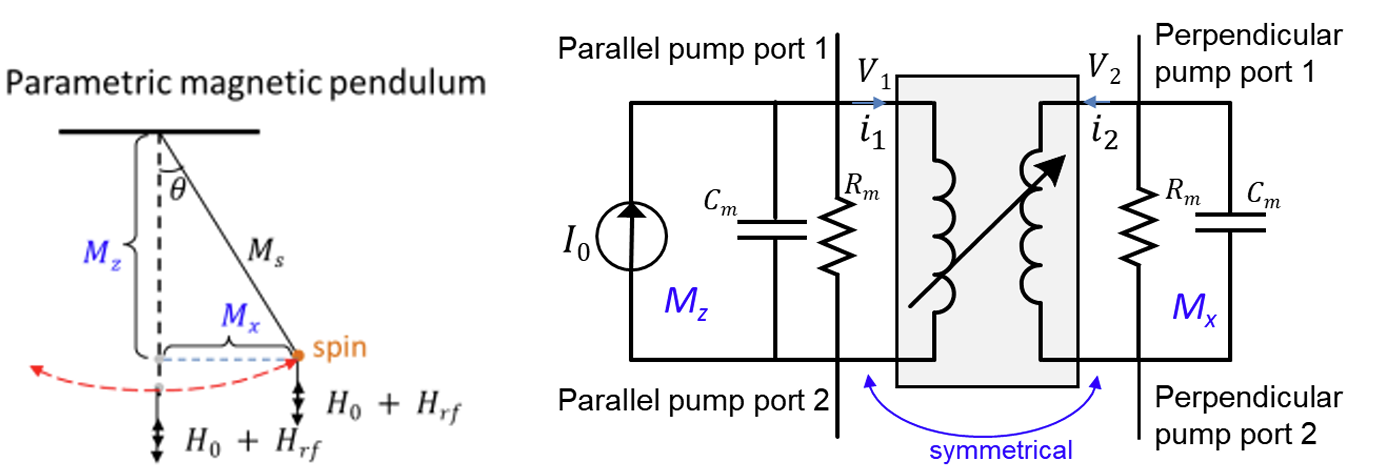

- $H_0$ is represented by the gravity force in the pendulum, and by $I_0$ in the circuit equivalent.
- The resonant circuits represent the magnetization oscillation along x and y ($M_x,M_y$).

From 1. we have already the R, L, C values & Derive RLC equivalent of pendulum --> Adapt circuit equivalent

4. **Cascaded model**

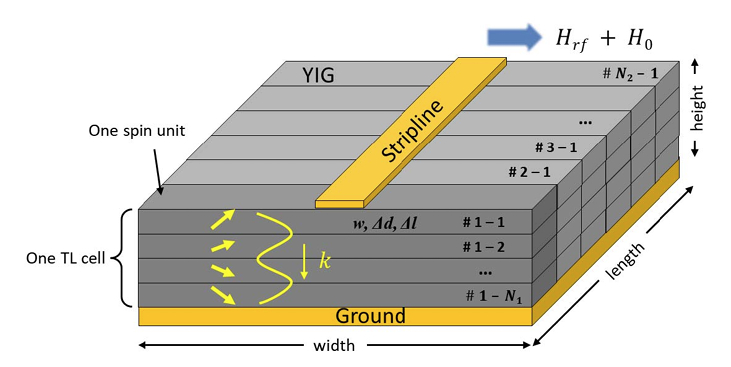

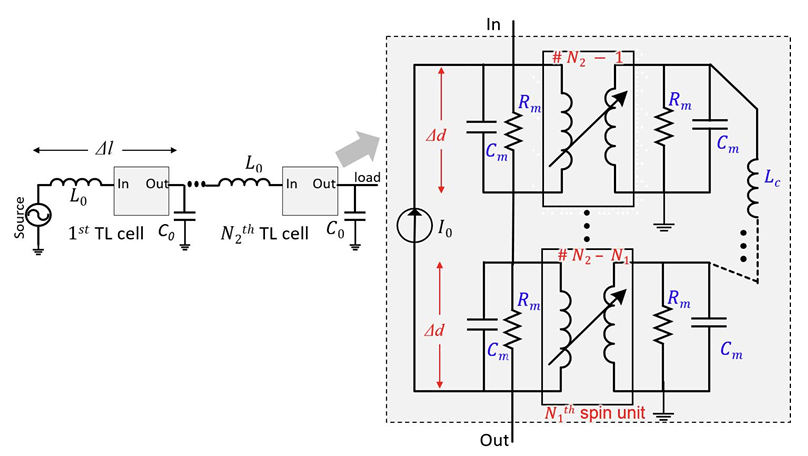

### Assumptions
- R,L,C values obtained from linearized LLG equation (neglect magnetization variation along symmetry axis)
- Same R,L,C for all the film
- Structure of YIG ? How would poly or cryst change the picture?
- Change in $M_y$ is neglected for EM/spintronics integration
- $H_0$ and $H_{rf}$ parallel
- Spins coupled at the same time in the limiting regime
- Applicable to other FSL topologies ?


Models so far:
- Models based on micromagnetics are only capable of computing very small dimensions up to 100 nm.
- Moreover, magnetic models are not compatible to designs and simulations in the circuit system. 
- Empirical circuit models are specific.
